In [1]:
##  Import libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [2]:
## Setting folder paths

project_folder = Path.cwd()

if project_folder.name == "notebooks":
    project_folder = project_folder.parent

raw_folder = project_folder / "data" / "raw"
processed_folder = project_folder / "data" / "processed"
processed_folder.mkdir(parents=True, exist_ok=True)

file_names = [
    "users.csv",
    "channels.csv",
    "videos.csv",
    "sessions.csv",
    "events.csv",
    "experiment_assignments.csv"
]

missing_files = [name for name in file_names if not (raw_folder / name).exists()]

if missing_files:
    raise FileNotFoundError(
        "These files are missing from data/raw: " + ", ".join(missing_files)
    )

print("Raw folder:", raw_folder)
print("Processed folder:", processed_folder)
print("All six raw files were found.")


Raw folder: c:\Users\naren\OneDrive\Desktop\Data Analytics\Projects\Portfolio Centerpiece Projects using AI\end-to-end-google-product-analytics-platform\data\raw
Processed folder: c:\Users\naren\OneDrive\Desktop\Data Analytics\Projects\Portfolio Centerpiece Projects using AI\end-to-end-google-product-analytics-platform\data\processed
All six raw files were found.


In [3]:
## Loading every CSV

users = pd.read_csv(raw_folder / "users.csv", low_memory=False)
channels = pd.read_csv(raw_folder / "channels.csv", low_memory=False)
videos = pd.read_csv(raw_folder / "videos.csv", low_memory=False)
sessions = pd.read_csv(raw_folder / "sessions.csv", low_memory=False)
events = pd.read_csv(raw_folder / "events.csv", low_memory=False)
experiments = pd.read_csv(
    raw_folder / "experiment_assignments.csv",
    low_memory=False
)

tables = {
    "users": users,
    "channels": channels,
    "videos": videos,
    "sessions": sessions,
    "events": events,
    "experiment_assignments": experiments
}

print("All files loaded successfully.")


All files loaded successfully.


In [4]:
## cross checking Structure

structure = []

for name, data in tables.items():
    memory_mb = data.memory_usage(deep=True).sum() / (1024 ** 2)

    structure.append({
        "table": name,
        "rows": len(data),
        "columns": data.shape[1],
        "memory_mb": round(memory_mb, 2)
    })

structure = pd.DataFrame(structure)
display(structure)


,table,rows,columns,memory_mb
0,users,25025,10,13.32
1,channels,2000,8,0.87
2,videos,10000,10,4.50
3,sessions,217113,10,123.45
4,events,1612230,13,833.17
5,experiment_assignments,12500,6,3.65


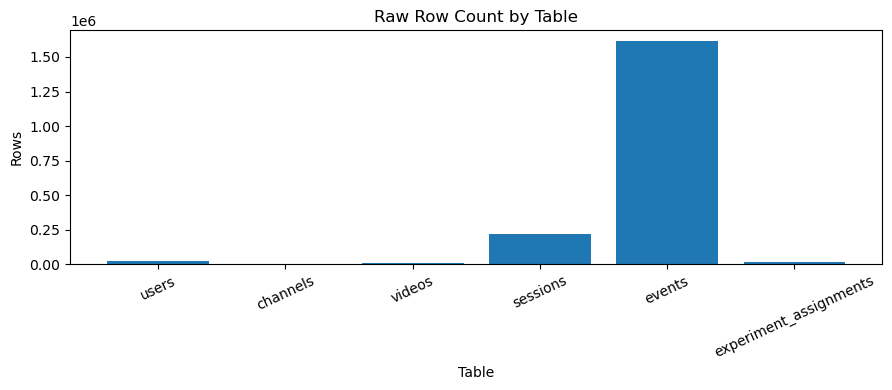

In [5]:
plt.figure(figsize=(9, 4))
plt.bar(structure["table"], structure["rows"])
plt.title("Raw Row Count by Table")
plt.xlabel("Table")
plt.ylabel("Rows")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


In [7]:
### Checking primary-key 

primary_keys = {
    "users": ["user_id"],
    "channels": ["channel_id"],
    "videos": ["video_id"],
    "sessions": ["session_id"],
    "events": ["event_id"],
    "experiment_assignments": ["experiment_id", "user_id"]
}

key_check = []

for name, keys in primary_keys.items():
    data = tables[name]

    key_check.append({
        "table": name,
        "rows": len(data),
        "unique_keys": len(data.drop_duplicates(subset=keys)),
        "duplicate_keys": int(data.duplicated(subset=keys).sum())
    })

key_check = pd.DataFrame(key_check)
display(key_check)


,table,rows,unique_keys,duplicate_keys
0,users,25025,25000,25
1,channels,2000,2000,0
2,videos,10000,10000,0
3,sessions,217113,216464,649
4,events,1612230,1609012,3218
5,experiment_assignments,12500,12500,0


In [8]:
## Checking raw-data quality


valid_events = {
    "app_open", "homepage_view", "video_impression", "video_click",
    "video_start", "video_progress_25", "video_progress_50",
    "video_progress_75", "video_complete", "search", "like",
    "comment", "share", "subscribe_channel", "save_to_watch_later",
    "session_end"
}

valid_countries = {
    "Australia", "Brazil", "Canada", "France", "Germany", "India",
    "Indonesia", "Italy", "Japan", "Mexico", "Nigeria", "Pakistan",
    "Philippines", "South Korea", "Spain", "Thailand", "Turkey",
    "United Kingdom", "United States", "Vietnam", "Unknown"
}

valid_devices = {
    "Desktop", "Game Console", "Mobile", "TV", "Tablet", "Unknown"
}

valid_traffic_sources = {
    "Channel Page", "External Link", "Homepage Recommendation",
    "Notifications", "Subscriptions Feed", "Suggested Video",
    "YouTube Search", "Unknown"
}

valid_subscription_types = {
    "Free", "Premium Trial", "YouTube Premium", "Unknown"
}

valid_variants = {"Control", "Treatment"}


def quality_report(users, channels, videos, sessions, events, experiments):
    report = {}

    all_tables = [users, channels, videos, sessions, events, experiments]

    report["Missing values"] = int(
        sum(data.isna().sum().sum() for data in all_tables)
    )

    report["Exact duplicate rows"] = int(
        sum(data.duplicated().sum() for data in all_tables)
    )

    report["Duplicate primary keys"] = int(
        users.duplicated("user_id").sum()
        + channels.duplicated("channel_id").sum()
        + videos.duplicated("video_id").sum()
        + sessions.duplicated("session_id").sum()
        + events.duplicated("event_id").sum()
        + experiments.duplicated(["experiment_id", "user_id"]).sum()
    )

    date_columns = [
        (users, "signup_date"),
        (channels, "channel_created_date"),
        (videos, "upload_date"),
        (sessions, "session_start_timestamp"),
        (sessions, "session_end_timestamp"),
        (events, "event_timestamp"),
        (experiments, "assignment_date"),
        (experiments, "first_exposure_date")
    ]

    invalid_dates = 0

    for data, column in date_columns:
        converted = pd.to_datetime(data[column], errors="coerce")
        invalid_dates += int(data[column].notna().sum() - converted.notna().sum())

    report["Invalid dates"] = invalid_dates

    video_duration = pd.to_numeric(
        videos["duration_seconds"], errors="coerce"
    )
    watch_duration = pd.to_numeric(
        events["watch_duration_seconds"], errors="coerce"
    )
    video_position = pd.to_numeric(
        events["video_position_seconds"], errors="coerce"
    )

    report["Negative durations"] = int(
        (video_duration < 0).sum()
        + (watch_duration < 0).sum()
        + (video_position < 0).sum()
    )

    report["Invalid event names"] = int(
        (~events["event_name"].isin(valid_events)).sum()
    )

    invalid_categories = (
        (~users["country"].isin(valid_countries) & users["country"].notna()).sum()
        + (~users["preferred_device"].isin(valid_devices)
           & users["preferred_device"].notna()).sum()
        + (~users["subscription_type"].isin(valid_subscription_types)
           & users["subscription_type"].notna()).sum()
        + (~sessions["device_type"].isin(valid_devices)
           & sessions["device_type"].notna()).sum()
        + (~sessions["traffic_source"].isin(valid_traffic_sources)
           & sessions["traffic_source"].notna()).sum()
        + (~experiments["variant"].isin(valid_variants)
           & experiments["variant"].notna()).sum()
    )

    report["Invalid categories"] = int(invalid_categories)

    orphan_keys = (
        (~sessions["user_id"].isin(users["user_id"])).sum()
        + (~videos["channel_id"].isin(channels["channel_id"])).sum()
        + (~events["session_id"].isin(sessions["session_id"])).sum()
        + (~events["user_id"].isin(users["user_id"])).sum()
        + (events["video_id"].notna()
           & ~events["video_id"].isin(videos["video_id"])).sum()
        + (events["channel_id"].notna()
           & ~events["channel_id"].isin(channels["channel_id"])).sum()
        + (~experiments["user_id"].isin(users["user_id"])).sum()
    )

    report["Orphan foreign keys"] = int(orphan_keys)

    clean_sessions = sessions.drop_duplicates("session_id")
    start_time = clean_sessions.set_index("session_id")[
        "session_start_timestamp"
    ]
    end_time = clean_sessions.set_index("session_id")[
        "session_end_timestamp"
    ]

    event_time = pd.to_datetime(events["event_timestamp"], errors="coerce")
    event_start = pd.to_datetime(
        events["session_id"].map(start_time), errors="coerce"
    )
    event_end = pd.to_datetime(
        events["session_id"].map(end_time), errors="coerce"
    )

    outside_session = (
        (event_time < event_start) | (event_time > event_end)
    )

    report["Events outside session time"] = int(outside_session.sum())

    duration_lookup = videos.drop_duplicates("video_id").set_index(
        "video_id"
    )["duration_seconds"]

    video_length = pd.to_numeric(
        events["video_id"].map(duration_lookup), errors="coerce"
    )

    report["Watch duration over video duration"] = int(
        (watch_duration > video_length).sum()
    )

    multiple_groups = experiments.groupby(
        ["experiment_id", "user_id"]
    )["variant"].nunique()

    report["Users in multiple experiment groups"] = int(
        (multiple_groups > 1).sum()
    )

    return pd.Series(report, name="count")


In [9]:
before_quality = quality_report(
    users, channels, videos, sessions, events, experiments
)

display(before_quality.to_frame())


,count
Missing values,6329269
Exact duplicate rows,3892
Duplicate primary keys,3892
Invalid dates,0
Negative durations,0
Invalid event names,0
Invalid categories,6032
Orphan foreign keys,0
Events outside session time,0
Watch duration over video duration,0


In [ ]:
# Correcting data types and standardizing text


# Removing spaces from every text column.
for data in tables.values():
    for column in data.select_dtypes(include="object").columns:
        data[column] = data[column].astype("string").str.strip()


def use_standard_names(series, standard_values, extra_names=None):
    name_map = {value.casefold(): value for value in standard_values}

    if extra_names:
        name_map.update(extra_names)

    cleaned = series.astype("string").str.strip()
    return cleaned.str.casefold().map(name_map).fillna(cleaned)


country_names = sorted(valid_countries - {"Unknown"})
device_names = sorted(valid_devices - {"Unknown"})
traffic_names = sorted(valid_traffic_sources - {"Unknown"})
subscription_names = sorted(valid_subscription_types - {"Unknown"})

country_aliases = {
    "usa": "United States",
    "u.s.": "United States",
    "us": "United States"
}

subscription_aliases = {
    "premium": "YouTube Premium"
}

users["country"] = use_standard_names(
    users["country"], country_names, country_aliases
)

users["preferred_device"] = use_standard_names(
    users["preferred_device"], device_names
)

users["subscription_type"] = use_standard_names(
    users["subscription_type"], subscription_names, subscription_aliases
)

channels["creator_country"] = use_standard_names(
    channels["creator_country"], country_names, country_aliases
)

sessions["country"] = use_standard_names(
    sessions["country"], country_names, country_aliases
)

sessions["device_type"] = use_standard_names(
    sessions["device_type"], device_names
)

sessions["traffic_source"] = use_standard_names(
    sessions["traffic_source"], traffic_names
)


In [ ]:
# Converting dates and timestamps.
users["signup_date"] = pd.to_datetime(
    users["signup_date"], errors="coerce"
)

channels["channel_created_date"] = pd.to_datetime(
    channels["channel_created_date"], errors="coerce"
)

videos["upload_date"] = pd.to_datetime(
    videos["upload_date"], errors="coerce"
)

sessions["session_start_timestamp"] = pd.to_datetime(
    sessions["session_start_timestamp"], errors="coerce"
)

sessions["session_end_timestamp"] = pd.to_datetime(
    sessions["session_end_timestamp"], errors="coerce"
)

events["event_timestamp"] = pd.to_datetime(
    events["event_timestamp"], errors="coerce"
)

experiments["assignment_date"] = pd.to_datetime(
    experiments["assignment_date"], errors="coerce"
)

experiments["first_exposure_date"] = pd.to_datetime(
    experiments["first_exposure_date"], errors="coerce"
)

# Convert numeric columns.
videos["duration_seconds"] = pd.to_numeric(
    videos["duration_seconds"], errors="coerce"
).round().astype("Int64")

videos["title_length"] = pd.to_numeric(
    videos["title_length"], errors="coerce"
).round().astype("Int64")

events["event_sequence_number"] = pd.to_numeric(
    events["event_sequence_number"], errors="coerce"
).round().astype("Int64")

events["watch_duration_seconds"] = pd.to_numeric(
    events["watch_duration_seconds"], errors="coerce"
)

events["video_position_seconds"] = pd.to_numeric(
    events["video_position_seconds"], errors="coerce"
)


def make_boolean(series):
    return (
        series.astype("string")
        .str.lower()
        .map({"true": True, "false": False, "1": True, "0": False})
        .astype("boolean")
    )


events["is_autoplay"] = make_boolean(events["is_autoplay"])
experiments["eligible_flag"] = make_boolean(
    experiments["eligible_flag"]
)


In [ ]:
# 3.7 Handling duplicates, missing values and invalid records


# Remove duplicate primary keys.
users = users.drop_duplicates("user_id", keep="first").copy()
channels = channels.drop_duplicates("channel_id", keep="first").copy()
videos = videos.drop_duplicates("video_id", keep="first").copy()
sessions = sessions.drop_duplicates("session_id", keep="first").copy()
events = events.drop_duplicates("event_id", keep="first").copy()
experiments = experiments.drop_duplicates(
    ["experiment_id", "user_id"], keep="first"
).copy()


In [ ]:
# Removing rows missing fields that are required.
users = users.dropna(subset=["user_id", "signup_date"])
channels = channels.dropna(
    subset=["channel_id", "channel_name", "channel_created_date"]
)
videos = videos.dropna(
    subset=["video_id", "channel_id", "upload_date", "duration_seconds"]
)
sessions = sessions.dropna(
    subset=[
        "session_id", "user_id",
        "session_start_timestamp", "session_end_timestamp"
    ]
)
events = events.dropna(
    subset=[
        "event_id", "session_id", "user_id",
        "event_timestamp", "event_name", "event_sequence_number"
    ]
)
experiments = experiments.dropna(
    subset=[
        "experiment_id", "user_id", "variant",
        "assignment_date", "first_exposure_date"
    ]
)


In [ ]:
# Filling only fields where a replacement has a clear meaning.
users["region"] = users["region"].fillna("Unknown")
users["age_group"] = users["age_group"].fillna("Unknown")
users["preferred_language"] = users[
    "preferred_language"
].fillna("Unknown")

channels["primary_language"] = channels[
    "primary_language"
].fillna("Unknown")
channels["content_rating"] = channels[
    "content_rating"
].fillna("Unknown")

videos["content_rating"] = videos["content_rating"].fillna("Unknown")
videos["thumbnail_style"] = videos[
    "thumbnail_style"
].fillna("Unknown")
videos["title_length"] = videos["title_length"].fillna(
    videos["title_length"].median()
).round().astype("Int64")

sessions["app_version"] = sessions["app_version"].fillna("Unknown")
sessions["network_type"] = sessions["network_type"].fillna("Unknown")

events["watch_duration_seconds"] = events[
    "watch_duration_seconds"
].fillna(0)

events["video_position_seconds"] = events[
    "video_position_seconds"
].fillna(0)

events["is_autoplay"] = events["is_autoplay"].fillna(False)

events.loc[
    events["event_name"].eq("search")
    & events["search_category"].isna(),
    "search_category"
] = "Unknown"

events.loc[
    ~events["event_name"].eq("search"),
    "search_category"
] = "Not Applicable"

events["recommendation_source"] = events[
    "recommendation_source"
].fillna("Not Applicable")

experiments["eligible_flag"] = experiments[
    "eligible_flag"
].fillna(False)


In [ ]:
# Replacing invalid descriptive categories with Unknown.
users.loc[
    ~users["country"].isin(valid_countries), "country"
] = "Unknown"

users.loc[
    ~users["preferred_device"].isin(valid_devices), "preferred_device"
] = "Unknown"

users.loc[
    ~users["subscription_type"].isin(valid_subscription_types),
    "subscription_type"
] = "Unknown"

sessions.loc[
    ~sessions["device_type"].isin(valid_devices), "device_type"
] = "Unknown"

sessions.loc[
    ~sessions["traffic_source"].isin(valid_traffic_sources),
    "traffic_source"
] = "Unknown"

# Invalid event names and experiment variants cannot be analysed safely.
events = events[events["event_name"].isin(valid_events)].copy()
experiments = experiments[
    experiments["variant"].isin(valid_variants)
].copy()


In [ ]:
# Fixing invalid durations and timestamp order.
videos = videos[videos["duration_seconds"] > 0].copy()

events.loc[
    events["watch_duration_seconds"] < 0,
    "watch_duration_seconds"
] = 0

events.loc[
    events["video_position_seconds"] < 0,
    "video_position_seconds"
] = 0

sessions = sessions[
    sessions["session_end_timestamp"]
    >= sessions["session_start_timestamp"]
].copy()

experiments = experiments[
    experiments["first_exposure_date"]
    >= experiments["assignment_date"]
].copy()


In [16]:
# checking and cleaning table relationships


# Keeping only records whose parent keys exist.
sessions = sessions[
    sessions["user_id"].isin(users["user_id"])
].copy()

videos = videos[
    videos["channel_id"].isin(channels["channel_id"])
].copy()

events = events[
    events["session_id"].isin(sessions["session_id"])
    & events["user_id"].isin(users["user_id"])
].copy()

events = events[
    events["video_id"].isna()
    | events["video_id"].isin(videos["video_id"])
].copy()

events = events[
    events["channel_id"].isna()
    | events["channel_id"].isin(channels["channel_id"])
].copy()

experiments = experiments[
    experiments["user_id"].isin(users["user_id"])
].copy()


In [17]:
# The event user must match the user who owns the session.
session_user = sessions.set_index("session_id")["user_id"]

events = events[
    events["user_id"].eq(events["session_id"].map(session_user))
].copy()

# Every event must occur inside its session.
session_start = sessions.set_index("session_id")[
    "session_start_timestamp"
]
session_end = sessions.set_index("session_id")[
    "session_end_timestamp"
]

event_start = events["session_id"].map(session_start)
event_end = events["session_id"].map(session_end)

events = events[
    events["event_timestamp"].between(event_start, event_end)
].copy()


In [18]:
# setting: Watch duration cannot be greater than video duration.
video_length = videos.set_index("video_id")["duration_seconds"]
event_video_length = events["video_id"].map(video_length)

has_video = events["video_id"].notna()

events.loc[
    has_video,
    "watch_duration_seconds"
] = np.minimum(
    events.loc[has_video, "watch_duration_seconds"],
    event_video_length.loc[has_video]
)

events.loc[
    has_video,
    "video_position_seconds"
] = np.minimum(
    events.loc[has_video, "video_position_seconds"],
    event_video_length.loc[has_video]
)

events["watch_duration_seconds"] = events[
    "watch_duration_seconds"
].round().astype("Int64")

events["video_position_seconds"] = events[
    "video_position_seconds"
].round().astype("Int64")


In [ ]:
# Removing users assigned to more than one variant in the same experiment.
variant_count = experiments.groupby(
    ["experiment_id", "user_id"]
)["variant"].nunique()

mixed_users = variant_count[variant_count > 1].reset_index()

if not mixed_users.empty:
    mixed_keys = set(
        zip(mixed_users["experiment_id"], mixed_users["user_id"])
    )

    row_keys = list(
        zip(experiments["experiment_id"], experiments["user_id"])
    )

    experiments = experiments[
        [key not in mixed_keys for key in row_keys]
    ].copy()


In [20]:
## doing little feature enginering : Create basic features



sessions["session_duration_minutes"] = (
    sessions["session_end_timestamp"]
    - sessions["session_start_timestamp"]
).dt.total_seconds().div(60).round(2)

events["watch_duration_minutes"] = (
    events["watch_duration_seconds"].div(60).round(2)
)

events["event_date"] = events["event_timestamp"].dt.date
events["event_hour"] = events["event_timestamp"].dt.hour
events["day_of_week"] = events["event_timestamp"].dt.day_name()
events["is_weekend"] = events["day_of_week"].isin(
    ["Saturday", "Sunday"]
)

engagement_events = {
    "like", "comment", "share",
    "subscribe_channel", "save_to_watch_later"
}

events["is_engagement_event"] = events[
    "event_name"
].isin(engagement_events)

events["is_video_completion"] = events[
    "event_name"
].eq("video_complete")


In [21]:
#Final validation


clean_tables = {
    "users": users,
    "channels": channels,
    "videos": videos,
    "sessions": sessions,
    "events": events,
    "experiment_assignments": experiments
}

after_quality = quality_report(
    users, channels, videos, sessions, events, experiments
)

quality_summary = pd.concat(
    [before_quality, after_quality],
    axis=1
)

quality_summary.columns = ["before_cleaning", "after_cleaning"]
quality_summary["fixed"] = (
    quality_summary["before_cleaning"]
    - quality_summary["after_cleaning"]
)

display(quality_summary)


,before_cleaning,after_cleaning,fixed
Missing values,6329269,7416471,-1087202
Exact duplicate rows,3892,0,3892
Duplicate primary keys,3892,0,3892
Invalid dates,0,0,0
Negative durations,0,0,0
Invalid event names,0,0,0
Invalid categories,6032,0,6032
Orphan foreign keys,0,0,0
Events outside session time,0,0,0
Watch duration over video duration,0,0,0


In [22]:
final_rows = []

for name, data in clean_tables.items():
    final_rows.append({
        "table": name,
        "cleaned_rows": len(data),
        "columns": data.shape[1],
        "missing_values": int(data.isna().sum().sum())
    })

final_rows = pd.DataFrame(final_rows)
display(final_rows)


,table,cleaned_rows,columns,missing_values
0,users,25000,10,8248
1,channels,2000,8,54
2,videos,10000,10,645
3,sessions,216464,11,7627
4,events,1609012,20,7399897
5,experiment_assignments,12500,6,0


In [23]:
# Final relationship checks.
relationship_check = pd.Series({
    "sessions_without_user": int(
        (~sessions["user_id"].isin(users["user_id"])).sum()
    ),
    "videos_without_channel": int(
        (~videos["channel_id"].isin(channels["channel_id"])).sum()
    ),
    "events_without_session": int(
        (~events["session_id"].isin(sessions["session_id"])).sum()
    ),
    "events_without_user": int(
        (~events["user_id"].isin(users["user_id"])).sum()
    ),
    "events_with_invalid_video": int(
        (
            events["video_id"].notna()
            & ~events["video_id"].isin(videos["video_id"])
        ).sum()
    ),
    "events_with_invalid_channel": int(
        (
            events["channel_id"].notna()
            & ~events["channel_id"].isin(channels["channel_id"])
        ).sum()
    ),
    "experiment_users_missing": int(
        (~experiments["user_id"].isin(users["user_id"])).sum()
    )
}, name="invalid_rows")

display(relationship_check.to_frame())


,invalid_rows
sessions_without_user,0
videos_without_channel,0
events_without_session,0
events_without_user,0
events_with_invalid_video,0
events_with_invalid_channel,0
experiment_users_missing,0


In [ ]:
# Exporting cleaned files

output_files = {
    "cleaned_users.csv": users,
    "cleaned_channels.csv": channels,
    "cleaned_videos.csv": videos,
    "cleaned_sessions.csv": sessions,
    "cleaned_events.csv": events,
    "cleaned_experiment_assignments.csv": experiments
}

for file_name, data in output_files.items():
    output_path = processed_folder / file_name
    data.to_csv(output_path, index=False)
    print("Saved:", output_path)

quality_summary.to_csv(
    processed_folder / "data_quality_summary.csv"
)

relationship_check.to_csv(
    processed_folder / "relationship_validation.csv",
    header=True
)

print("\n save completed successfully.")
